# Week 01: Sunspot Butterfly Diagram

This notebook reads the provided sunspot group catalog and plots the classic solar "butterfly diagram" (latitude vs time of emergence).

## 1) Setup (run this first)

This project is designed to run on Google Colab. Run the setup cell below to install dependencies and configure the environment.

In [112]:
# Standard ButterflAI Colab setup — always run this first
import os
import subprocess
import sys
import numpy as np

repo_path = "/content/butterflai"
if not os.path.isdir(repo_path):
    subprocess.run(
        ["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path],
        check=True,
    )
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)

sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


  Installing from /content/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Google Colab
   Device   : cpu
   Seed     : 42


{'in_colab': True,
 'device': device(type='cpu'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

## 2) Load the Sunspot Group Catalog

We use the provided  file, which contains daily sunspot group measurements from 1825–2023.

In [113]:
import pandas as pd
from pathlib import Path

data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df.rename(columns={"year_month_day": "date"}, inplace=True)

# Keep only rows with valid latitude (sunspot groups)
df = df[df["latitude"].notna()].copy()

# Quick sanity check
df[["date", "latitude", "CYCLE"]].head()


/tmp/ipykernel_34315/1667494998.py:5: FutureWarning: The 'keep_date_col' keyword in pd.read_csv is deprecated and will be removed in a future version. Explicitly remove unwanted columns after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
/tmp/ipykernel_34315/1667494998.py:5: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)


,date,latitude,CYCLE
0,1825-11-05,-1.2,NaN
3,1825-11-08,-17.9,NaN
4,1825-11-09,-14.6,NaN
5,1825-11-10,-27.4,NaN
6,1825-11-11,-26.3,NaN


## 3) Plot the Butterfly Diagram

We plot emergence latitude vs. date. Points are colored by hemisphere (north vs south).

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


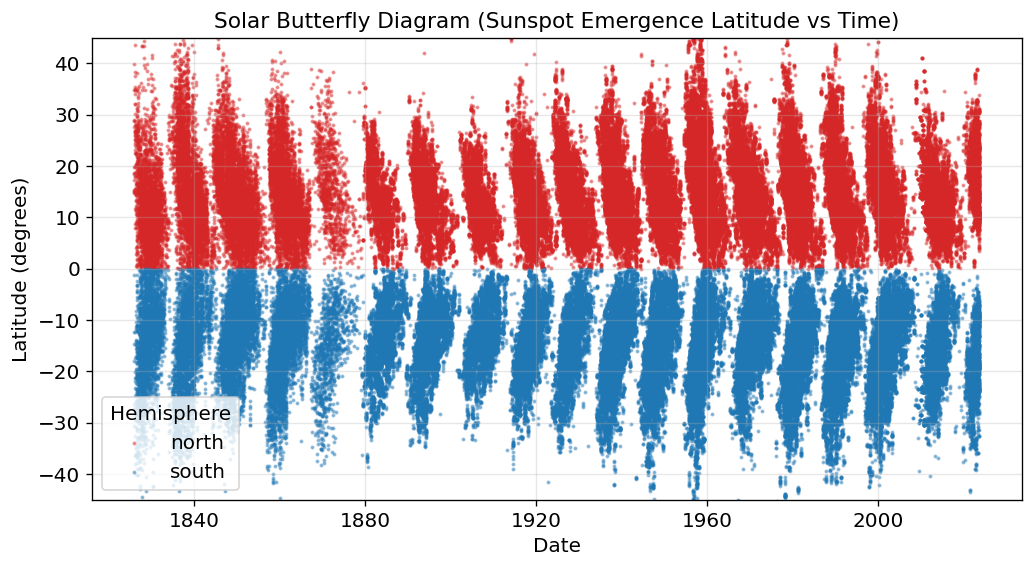

In [114]:
import matplotlib.pyplot as plt

df["hemisphere"] = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
colors = {"north": "tab:red", "south": "tab:blue"}

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 4) Exercise: Visualize Individual Solar Cycles

The butterfly diagram shows all cycles overlaid. Create a visualization that focuses on a single solar cycle (e.g., cycle 24, which is recent and well-observed).

**Task:**
- Filter the data to a specific cycle (use the  column).
- Plot the butterfly diagram for just that cycle.
- Experiment with different cycles and note any differences in shape or amplitude.

**Hint:** You can use the cycle column to filter.


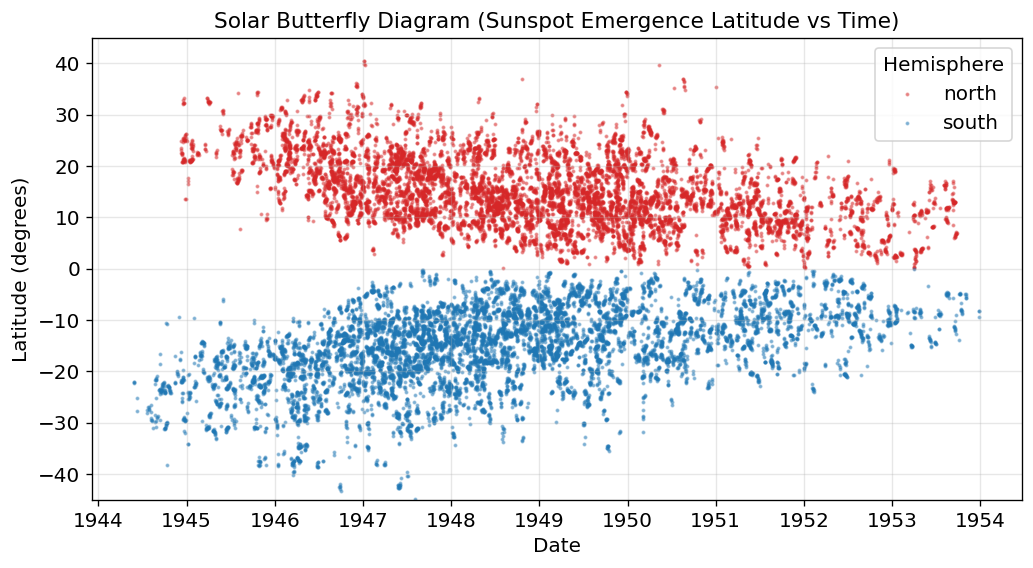

In [115]:
# Your code here: Visualize a single solar cycle

'''
Cycle Notes:

Cycle 24: max amp (disregarding very sparse data points) for north is about 40, max amp (disregarding very sparse data points) for south is about 35
Cycle 10: Similar shape as before, but more values in the extreme ends, data more sparse overall, and seems to have more data (check numerically)
Cycle 18: South has similar shape, north may have similar shape but is less pronounced due to lack of data earlier in the cycle, data quite clustered
          compared to 10, south overall seems to have more data

'''
cycle = 18

df_cycle = df[df['CYCLE'] == cycle] #filters for values in specified cycle

fig, ax = plt.subplots(figsize=(10, 5))
for hemi, group in df_cycle.groupby("hemisphere"):
    ax.scatter(group["date"], group["latitude"], s=2, c=colors[hemi], label=hemi, alpha=0.4)

ax.set_title("Solar Butterfly Diagram (Sunspot Emergence Latitude vs Time)")
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.legend(title="Hemisphere")
ax.set_ylim(-45, 45)
plt.show()


## 5) Exercise: Calculate Mean Latitudinal Paths

The "wings" of the butterfly diagram show the average latitude of sunspot emergence over time for each hemisphere.

**Task:**
- Group the data by hemisphere and calculate the mean latitude for each month/year.
- Plot the mean latitudinal path for the northern and southern hemispheres separately.
- Discuss: What does this tell us about the solar cycle's evolution?

**Hint:** Use  with  and date aggregation (e.g., resample by year).


/tmp/ipykernel_34315/2537634475.py:15: RuntimeWarning: Mean of empty slice
  avg_month = np.nanmean(df_hemi_year[df_hemi_year['date'].dt.month == month]['latitude'])


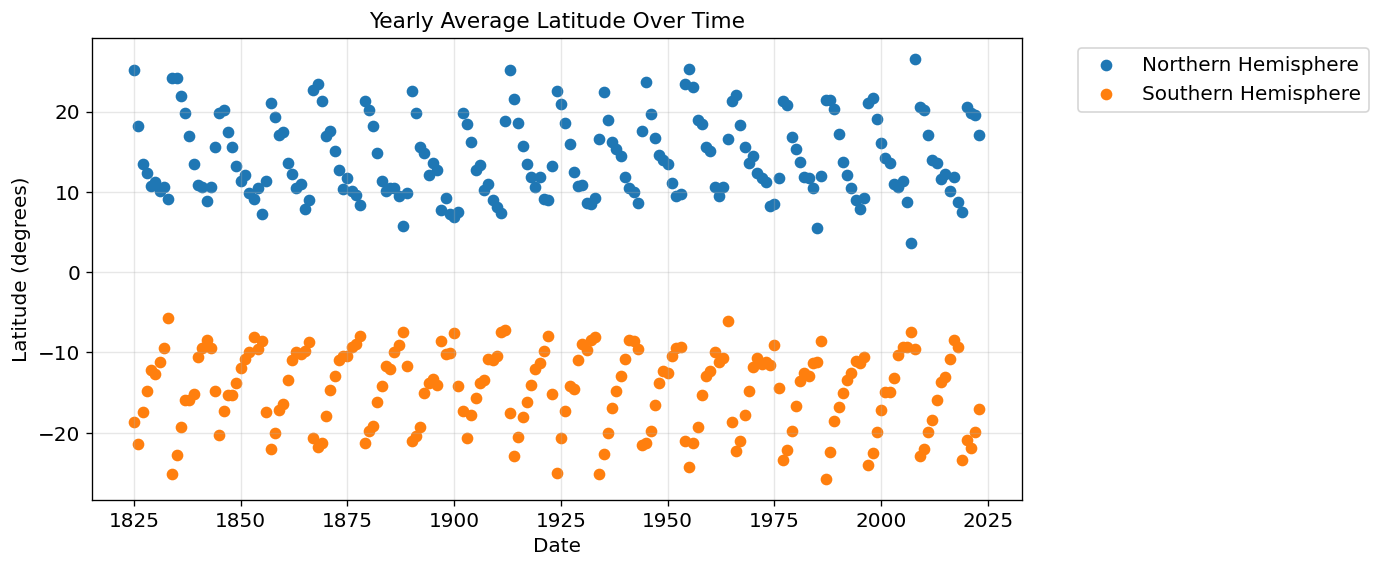

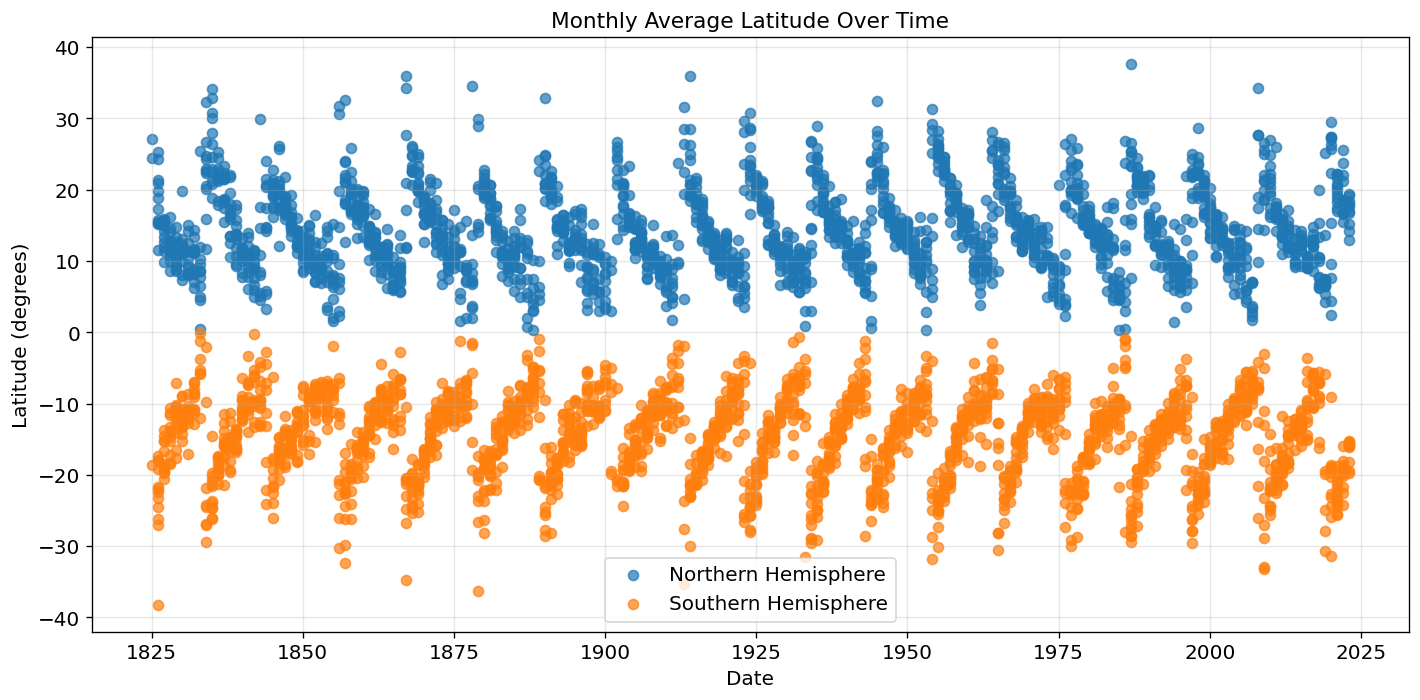

In [116]:
# Your code here: Calculate and plot mean latitudinal paths

year, north_avg_year, south_avg_year, north_avg_month, south_avg_month = [], [], [], [], []

#1825 to 2023
unique_years = df['date'].dt.year.unique()
for year in unique_years:
  for hemisphere in ['north', 'south']:
    df_hemi = df[df['hemisphere'] == hemisphere] #filters by hemisphere
    avg_year = np.nanmean(df_hemi[df_hemi['date'].dt.year == year]['latitude']) #calculates avg lat for that year and hemi
    df_hemi_year = df_hemi[df_hemi['date'].dt.year == year] #filters for both year and hemi
    month_list = [] #will hold avg for each month for that year and hemi

    for month in range(1, 13):
      avg_month = np.nanmean(df_hemi_year[df_hemi_year['date'].dt.month == month]['latitude'])
      month_list.append(avg_month)

    if hemisphere == 'north': # appends values to appropriate lists
      north_avg_year.append(avg_year)
      north_avg_month.append(month_list)
    else:
      south_avg_year.append(avg_year)
      south_avg_month.append(month_list)

fig, ax1 = plt.subplots(figsize=(10, 5)) #plots yearly avg comparison
ax1.scatter(unique_years, north_avg_year, label = 'Northern Hemisphere')
ax1.scatter(unique_years, south_avg_year, label = 'Southern Hemisphere')
ax1.set_title("Yearly Average Latitude Over Time")
ax1.set_xlabel("Date")
ax1.set_ylabel("Latitude (degrees)")
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=1)

north_avg_month_arr = np.array(north_avg_month)
south_avg_month_arr = np.array(south_avg_month)

fig, ax2 = plt.subplots(figsize=(12, 6))

for m in range(12): #plots monthly avg comparison across full timeline
    ax2.scatter(unique_years, north_avg_month_arr[:, m], label='Northern Hemisphere' if m == 0 else "", alpha=0.7, c = 'C0')
    ax2.scatter(unique_years, south_avg_month_arr[:, m], label='Southern Hemisphere' if m == 0 else "", alpha=0.7, c = 'C1')

ax2.set_title("Monthly Average Latitude Over Time")
ax2.set_xlabel("Date")
ax2.set_ylabel("Latitude (degrees)")
ax2.legend()
plt.tight_layout()

## 6) Reflection: Best Practices for AI-Assisted Learning

Throughout this program, you'll be working with AI assistants (like GitHub Copilot or Claude) to help with coding and understanding concepts.

**Task:**
- Ask your AI assistant: "What is the best way to prompt an AI assistant to help me learn machine learning and solar physics concepts effectively?"
- Write down their response and reflect: How will you apply this advice in future notebooks?

**Hint:** Be specific about what you want to learn and how you want the AI to explain it.


*AI response:*

Effective AI prompts for learning machine learning & solar physics:

Specify topic & goal – e.g., “Explain sunspots and the solar cycle for a beginner.”

Set depth & style – step-by-step, intuitive, mathematical, or coding-focused.

Combine theory & practice – include examples, exercises, or code demonstrations.

Use iterative or Socratic learning – break topics into small parts and quiz yourself.

Request analogies or comparisons – link new concepts to familiar ideas.

Ask for multi-modal explanations – diagrams, math, text, and code together.

Include review & reflection – summaries, bullet points, or quiz questions.

Tip: Keep prompts focused, build complexity gradually, and connect subjects (e.g., ML applied to solar flare prediction).

*Your reflection here:*
The suggestions given that I will try to incorporate more into my use of AI is to set clearer expectations on the kind of response I want i.e. step-by-step, mathematical, or coding in order to recieve a more helpful response as well as trying to break up material into small parts and ensuring I understand each part fully before moving on. For the latter suggestion, I will do better about trying to break it up myself beforehand but if I am struggling with that I will ask the AI for help in breaking the content up in a way that is efficient but still easily digestible.
